In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import re
import xlsxwriter

In [51]:
PROJECT_DIRS = [
    ('./MLP_Project',   'MLP',  'MLP'),
    ('./CDT_Project_w_o_TI_first_start', 'CDT',  'CDT 1-D CNN'),
    ('./LSTM_Project',  'LSTM', 'LSTM Attention'),
    ('./CNN_Project',  'CNN', 'CNN')
]

PLOTS_DIR = './Master_Thesis_Results'
os.makedirs(PLOTS_DIR, exist_ok=True)

In [52]:
# --- АКАДЕМИЧЕСКИЙ СТИЛЬ ---
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300, 'grid.alpha': 0.4,
    'lines.linewidth': 1.2, 'axes.spines.top': False, 'axes.spines.right': False
})

BASE_COLORS = {
    'MLP': '#c44e52', 'CDT 1-D CNN': '#4c72b0', 'LSTM Attention': '#55a868', 'Buy_Hold': '#888888',
}

In [53]:
def weighted_f_score(y_true, y_pred, beta1=0.5, beta2=0.125, beta3=0.125):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    N_tu = np.sum((y_true == 1) & (y_pred == 1))
    N_td = np.sum((y_true == 2) & (y_pred == 2))
    N_tf = np.sum((y_true == 0) & (y_pred == 0))
    N_tp = N_tu + N_td + beta3 * N_tf
    E1st = np.sum((y_pred == 1) & (y_true == 2)) + np.sum((y_pred == 2) & (y_true == 1))
    E2nd = np.sum((y_pred == 1) & (y_true == 0)) + np.sum((y_pred == 2) & (y_true == 0))
    E3rd = np.sum((y_pred == 0) & (y_true == 1)) + np.sum((y_pred == 0) & (y_true == 2))
    denominator = ((1 + beta1**2 + beta2**2) * N_tp + E1st + beta1**2 * E2nd + beta2**2 * E3rd)
    return (1 + beta1**2 + beta2**2) * N_tp / denominator if denominator != 0 else 0.0

In [54]:
def calculate_comprehensive_metrics(df, threshold=0.5, hold_period=24, commission=0.0003, rf_annual=0.09):
    df = df.copy().sort_values('DateTime')
    
    # Универсальная конвертация DateTime (для int64 timestamp, строк и datetime)
    if pd.api.types.is_integer_dtype(df['DateTime']):
        # Определяем единицу измерения (s, ms, us, ns) по размеру максимального числа
        max_val = df['DateTime'].max()
        if max_val > 1e17:
            unit = 'ns'  # Наносекунды (стандартный формат Parquet для datetime)
        elif max_val > 1e14:
            unit = 'us'  # Микросекунды
        elif max_val > 1e11:
            unit = 'ms'  # Миллисекунды (формат API Тинькофф)
        else:
            unit = 's'   # Секунды
        df['DateTime'] = pd.to_datetime(df['DateTime'], unit=unit)
    else:
        # Если это строки ("2024-01-01") или уже тип datetime64
        # errors='coerce' защитит от падения, если попадется мусор
        df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    
    df['Predicted'] = 0
    df.loc[(df['Prob_Up'] > threshold) & (df['Prob_Up'] >= df['Prob_Down']), 'Predicted'] = 1
    df.loc[(df['Prob_Down'] > threshold) & (df['Prob_Down'] > df['Prob_Up']), 'Predicted'] = 2

    positions, current_pos, hold_counter = [], 0, 0
    for pred in df['Predicted']:
        if hold_counter > 0: hold_counter -= 1
        else:
            if pred == 1: current_pos, hold_counter = 1, hold_period - 1   # Long
            # pred == 2 теперь означает кэш, а не шорт!
            elif pred == 2: current_pos, hold_counter = 0, hold_period - 1  # Cash (вместо -1)
            else: current_pos, hold_counter = 0, 0                          # Cash
        positions.append(current_pos)

    df['Position'] = positions
    df['Position'] = df['Position'].shift(1).fillna(0)
    df['Market_Return'] = df['Price'].pct_change().fillna(0)
    df['Strategy_Return_Gross'] = df['Position'] * df['Market_Return']
    df['Trade_Cost'] = df['Position'].diff().abs().fillna(0) * commission
    df['Strategy_Return_Net'] = df['Strategy_Return_Gross'] - df['Trade_Cost']
    df['Equity'] = (1 + df['Strategy_Return_Net']).cumprod()

    df_eval = df[(df["DateTime"] >= "2024-01-01") & (df["DateTime"] < "2026-01-01")].copy()
    if df_eval.empty or len(df_eval) < 10: return None, {}

    start_equity = df_eval['Equity'].iloc[0]
    df_eval['Equity_Norm'] = df_eval['Equity'] / start_equity

    wfs = weighted_f_score(df_eval['Actual'], df_eval['Predicted'])
    total_return = (df_eval['Equity_Norm'].iloc[-1] / df_eval['Equity_Norm'].iloc[0] - 1) * 100
    max_dd = ((df_eval['Equity_Norm'] / df_eval['Equity_Norm'].cummax() - 1).min()) * 100

    # Теперь DateTime уже точно datetime64, поэтому .dt.date сработает без ошибок
    df_eval['Date'] = df_eval['DateTime'].dt.date
    daily_returns = df_eval.groupby('Date')['Strategy_Return_Net'].apply(lambda x: (1 + x).prod() - 1)
    rf_daily = rf_annual / 252
    excess_daily = daily_returns - rf_daily
    sharpe = (excess_daily.mean() / excess_daily.std()) * np.sqrt(252) if excess_daily.std() > 0 else 0

    gross_profit = daily_returns[daily_returns > 0].sum()
    gross_loss = abs(daily_returns[daily_returns < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
    win_rate = (daily_returns > 0).mean() * 100

    # --- СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ (BOOTSTRAP) ---
    is_significant = "No"
    if len(daily_returns) > 30:
        observed_mean = daily_returns.mean()
        n_bootstraps = 5000
        boot_means = np.zeros(n_bootstraps)
        for i in range(n_bootstraps):
            boot_sample = np.random.choice(daily_returns, size=len(daily_returns), replace=True)
            boot_means[i] = boot_sample.mean()
            
        p_value = np.mean(boot_means <= 0)
        is_significant = "Yes" if p_value < 0.05 else "No"

    metrics = {
        'WFS': round(wfs, 4), 'Win Rate %': round(win_rate, 2),
        'Profit Factor': round(profit_factor, 2), 'Return, %': round(total_return, 2),
        'Max DD, %': round(max_dd, 2), 'Sharpe': round(sharpe, 2),
        'Signif.': is_significant, 'Trades': int(df_eval['Position'].diff().abs().sum() / 2)
    }
    return df_eval, metrics

In [55]:
def parse_model_variant(filename, short_id):
    core_name = re.sub(r'^[A-Z]+_', '', filename)
    core_name = re.sub(r'_A\d+[\.,]\d+_probs\.parquet$', '', core_name)
    variant = re.sub(rf'^{short_id}_?', '', core_name, flags=re.IGNORECASE)
    variant = variant.replace('_', ' ').strip()
    return variant

In [56]:
all_metrics_rows = []
equity_curves_store = {}
COLORS_DYNAMIC = {}

print("Scanning local project directories...")
for proj_dir, short_id, display_base in PROJECT_DIRS:
    results_dir = proj_dir # = os.path.join(proj_dir, 'results')
    if not os.path.exists(results_dir):
        print(f"  [SKIP] Directory not found: {results_dir}")
        continue

    files = [f for f in os.listdir(results_dir) if f.endswith('_probs.parquet')]
    if not files: continue

    for file in sorted(files):
        alpha_match = re.search(r'_A(\d+\.\d+)_probs\.parquet', file)
        alpha_val = alpha_match.group(1) if alpha_match else "X.XX"
        
        # --- УМНЫЙ ПАРСИНГ ИМЕНИ ---
        core_name = re.sub(r'_A\d+[\.,]\d+_probs\.parquet$', '', file)
        core_name = re.sub(r'_Regular', '', core_name, flags=re.IGNORECASE)
        core_name = re.sub(r'__+', '_', core_name).strip('_')
        
        # Ищем, где начинается ID модели (MLP, CDT, LSTM, CNN)
        match = re.search(rf'(_|^){short_id}(_|$)', core_name, re.IGNORECASE)
        if match:
            split_idx = match.start()
            ticker = core_name[:split_idx].strip('_') 
            variant = core_name[match.end():].strip('_').replace('_', ' ')
        else:
            parts = core_name.split('_', 1)
            ticker = parts[0]
            variant = parts[1].replace('_', ' ') if len(parts) > 1 else ''
        
        # Формируем красивое имя
        model_name = f"{display_base} ({variant})" if variant else display_base
        
        if model_name not in COLORS_DYNAMIC:
            COLORS_DYNAMIC[model_name] = BASE_COLORS.get(display_base, '#333333')

        df_raw = pd.read_parquet(os.path.join(results_dir, file))

        best_sharpe, best_thresh, best_eval_df, best_metrics = -999, 0, None, None
        for thresh in np.arange(0.10, 0.90, 0.05): 
            eval_df, metrics = calculate_comprehensive_metrics(df_raw, threshold=thresh)
            
            if metrics and metrics['Trades'] > 0:
                # ИСПРАВЛЕНО: Добавляем Alpha в строку таблицы
                row = {'Ticker': ticker, 'Model': model_name, 'Alpha': alpha_val, 'Threshold': thresh}
                row.update(metrics)
                all_metrics_rows.append(row)
                
                if metrics['Sharpe'] > best_sharpe:
                    best_sharpe, best_thresh, best_eval_df, best_metrics = metrics['Sharpe'], thresh, eval_df, metrics

        if best_eval_df is not None:
            if ticker not in equity_curves_store: equity_curves_store[ticker] = {}
            equity_curves_store[ticker][model_name] = (best_eval_df, best_thresh)
            # ИСПРАВЛЕНО: Добавили [A=...] в вывод консоли
            print(f"  {ticker} | {model_name} [A={alpha_val}]: Best Sharpe={best_metrics['Sharpe']:.2f} at T={best_thresh:.2f} ({best_metrics['Trades']} trades)")

metrics_df = pd.DataFrame(all_metrics_rows)

Scanning local project directories...
  GLDRUB_TOM | MLP (w TIs) [A=0.55]: Best Sharpe=0.28 at T=0.10 (7 trades)
  GLDRUB_TOM | MLP (w TIs) [A=0.80]: Best Sharpe=0.09 at T=0.10 (7 trades)
  GLDRUB_TOM | MLP (wo TIs) [A=0.55]: Best Sharpe=0.77 at T=0.10 (6 trades)
  GLDRUB_TOM | MLP (wo TIs) [A=0.80]: Best Sharpe=0.81 at T=0.10 (28 trades)
  LKOH | MLP (w TIs) [A=0.55]: Best Sharpe=-2.01 at T=0.10 (19 trades)
  LKOH | MLP (w TIs) [A=0.80]: Best Sharpe=-1.14 at T=0.10 (17 trades)
  LKOH | MLP (wo TIs) [A=0.55]: Best Sharpe=-0.73 at T=0.10 (11 trades)
  SBER | MLP (w TIs) [A=0.55]: Best Sharpe=-1.09 at T=0.10 (19 trades)
  SBER | MLP (w TIs) [A=0.80]: Best Sharpe=-1.81 at T=0.10 (21 trades)
  SBER | MLP (wo TIs) [A=0.55]: Best Sharpe=0.08 at T=0.10 (13 trades)
  SBER | MLP (wo TIs) [A=0.80]: Best Sharpe=-0.31 at T=0.10 (12 trades)
  YDEX | MLP (w TIs) [A=0.55]: Best Sharpe=0.26 at T=0.10 (21 trades)
  YDEX | MLP (w TIs) [A=0.80]: Best Sharpe=0.18 at T=0.10 (15 trades)
  YDEX | MLP (wo TIs

In [57]:
def plot_equity_curves(data_store, plots_dir):
    tickers = list(data_store.keys())
    n_tickers = len(tickers)
    if n_tickers == 0: return
    fig, axes = plt.subplots(n_tickers, 1, figsize=(12, 4 * n_tickers), sharex=True)
    if n_tickers == 1: axes = [axes]

    fig.suptitle('Cumulative Returns: Strategies vs. Buy & Hold (Out-of-Sample)', y=1.02, fontweight='bold')

    for i, ticker in enumerate(tickers):
        ax = axes[i]
        models_data = data_store[ticker]
        first_model_df = list(models_data.values())[0][0]
        bh_norm = first_model_df['Price'] / first_model_df['Price'].iloc[0]
        ax.plot(first_model_df['DateTime'], bh_norm, label='Buy & Hold', color=COLORS_DYNAMIC.get('Buy_Hold', '#888888'), linestyle='--', linewidth=1.5)

        for model_name, (df_eval, thresh) in models_data.items():
            color = COLORS_DYNAMIC.get(model_name, 'black')
            
            # ИСПРАВЛЕНИЕ: Добавлено :.2f для форматирования порога (например, 0.10 вместо 0.1)
            label_text = f'{model_name} (T={thresh:.2f})'
            ax.plot(df_eval['DateTime'], df_eval['Equity_Norm'], label=label_text, color=color, linewidth=1.5)

        ax.set_title(f'{ticker}', fontweight='bold')
        ax.set_ylabel('Cumulative Return')
        ax.legend(loc='upper left', frameon=False)
        ax.axhline(y=1.0, color='black', linestyle='-', alpha=0.2)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    plt.xlabel('Date')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'equity_curves.png'), bbox_inches='tight')
    plt.show()

In [58]:
def plot_metrics_comparison(metrics_df, plots_dir):
    if metrics_df.empty: return
    best_df = metrics_df.loc[metrics_df.groupby(['Ticker', 'Model'])['Sharpe'].idxmax()]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Performance Metrics Comparison by Ticker and Model', fontweight='bold', y=1.02)
    
    sns.barplot(data=best_df, x='Ticker', y='Return, %', hue='Model', ax=axes[0,0], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[0,0].axhline(0, color='gray', linewidth=0.8); axes[0,0].set_title('Total Return (%)'); axes[0,0].legend_.remove()
    
    sns.barplot(data=best_df, x='Ticker', y='Sharpe', hue='Model', ax=axes[0,1], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[0,1].axhline(0, color='gray', linewidth=0.8); axes[0,1].axhline(1, color='gray', linestyle='--', linewidth=0.8); axes[0,1].set_title('Sharpe Ratio'); axes[0,1].legend(frameon=False)
    
    sns.barplot(data=best_df, x='Ticker', y='Profit Factor', hue='Model', ax=axes[1,0], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[1,0].axhline(1, color='gray', linewidth=0.8); axes[1,0].set_title('Profit Factor'); axes[1,0].legend_.remove()
    
    sns.barplot(data=best_df, x='Ticker', y='WFS', hue='Model', ax=axes[1,1], palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.5)
    axes[1,1].set_title('Weighted F-Score'); axes[1,1].legend_.remove()

    for ax in axes.flat: ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'metrics_comparison.png'), bbox_inches='tight')
    plt.show()

In [59]:
def plot_risk_return_scatter(metrics_df, plots_dir):
    if metrics_df.empty: return
    best_df = metrics_df.loc[metrics_df.groupby(['Ticker', 'Model'])['Sharpe'].idxmax()]
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=best_df, x='Sharpe', y='Return, %', hue='Model', style='Ticker', s=150, palette=COLORS_DYNAMIC, edgecolor='black', linewidth=0.8)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(1, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Sharpe = 1 Threshold')
    plt.xlabel('Sharpe Ratio', fontweight='bold')
    plt.ylabel('Total Return (%)', fontweight='bold')
    plt.title('Risk-Adjusted Performance: Sharpe Ratio vs. Total Return', fontweight='bold')
    plt.legend(frameon=False)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'risk_return_scatter.png'), bbox_inches='tight')
    plt.show()

def plot_correlation_heatmap(metrics_df, plots_dir):
    if metrics_df.empty: return
    numeric_cols = ['WFS', 'Win Rate %', 'Return, %', 'Sharpe', 'Profit Factor', 'Max DD, %', 'Trades']
    corr_matrix = metrics_df[numeric_cols].corr()
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5, mask=mask, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Strategy Metrics', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'correlation_heatmap.png'), bbox_inches='tight')
    plt.show()


Generating unified academic visualizations...


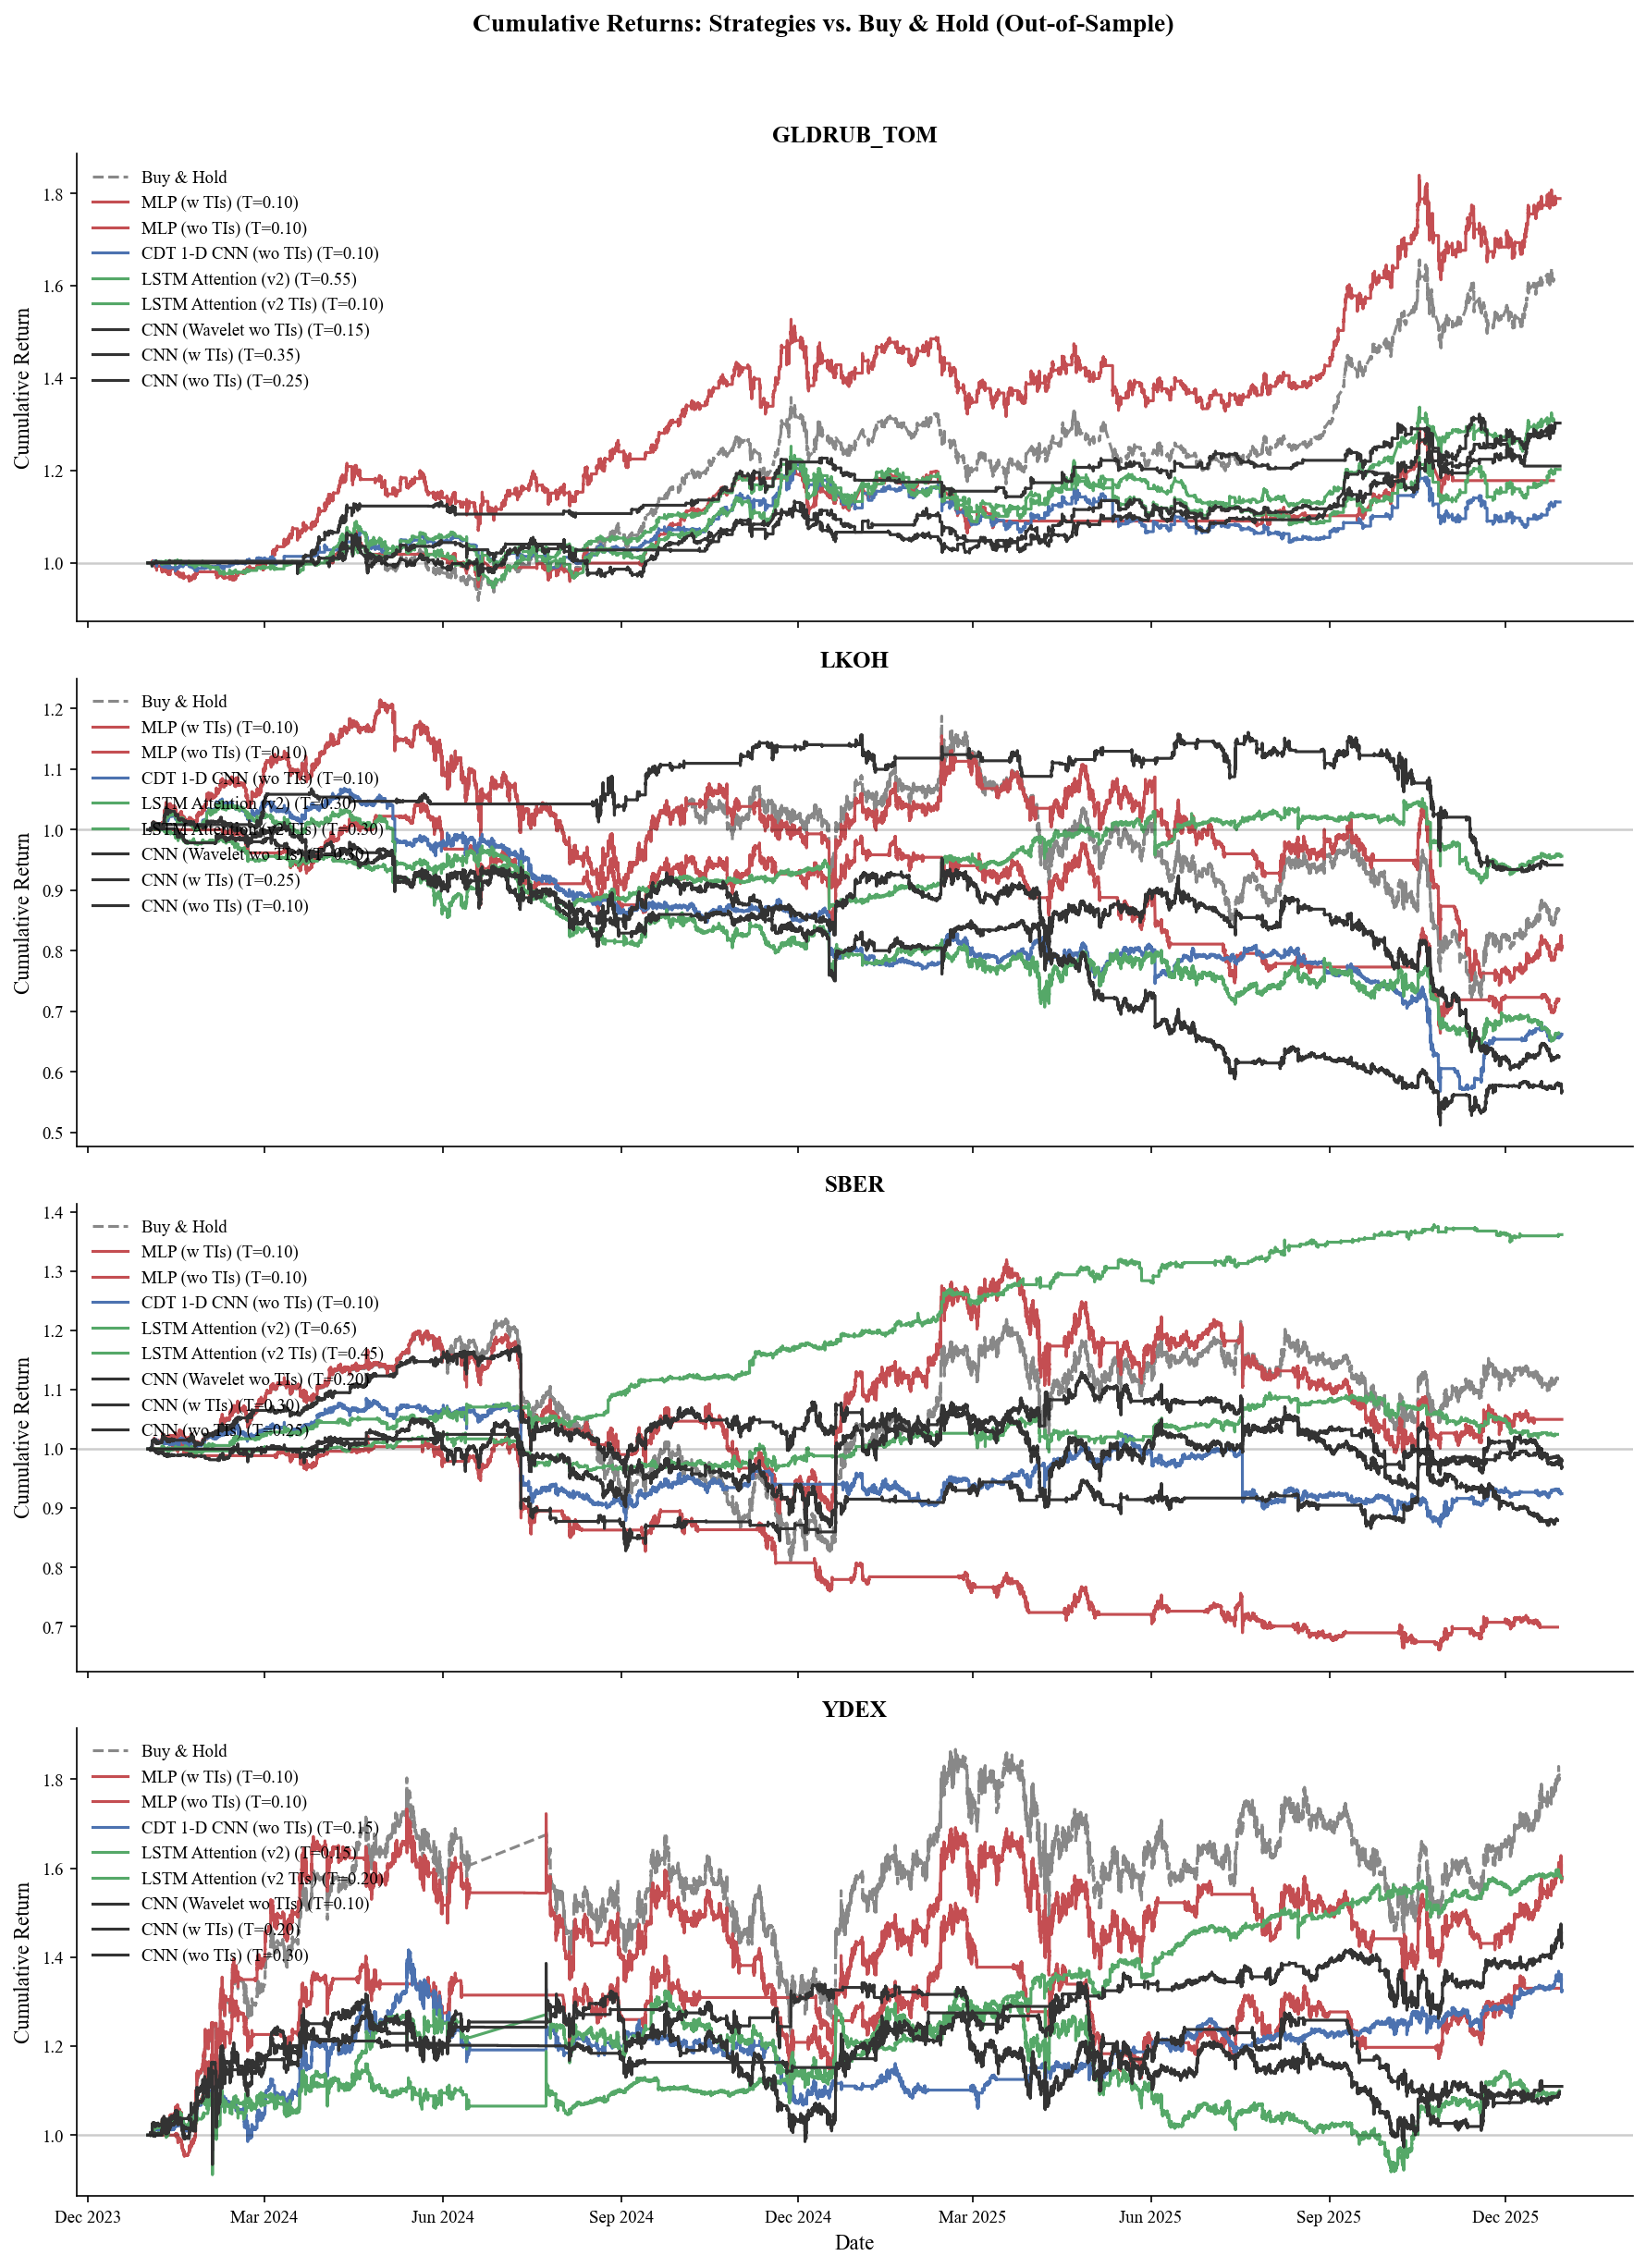

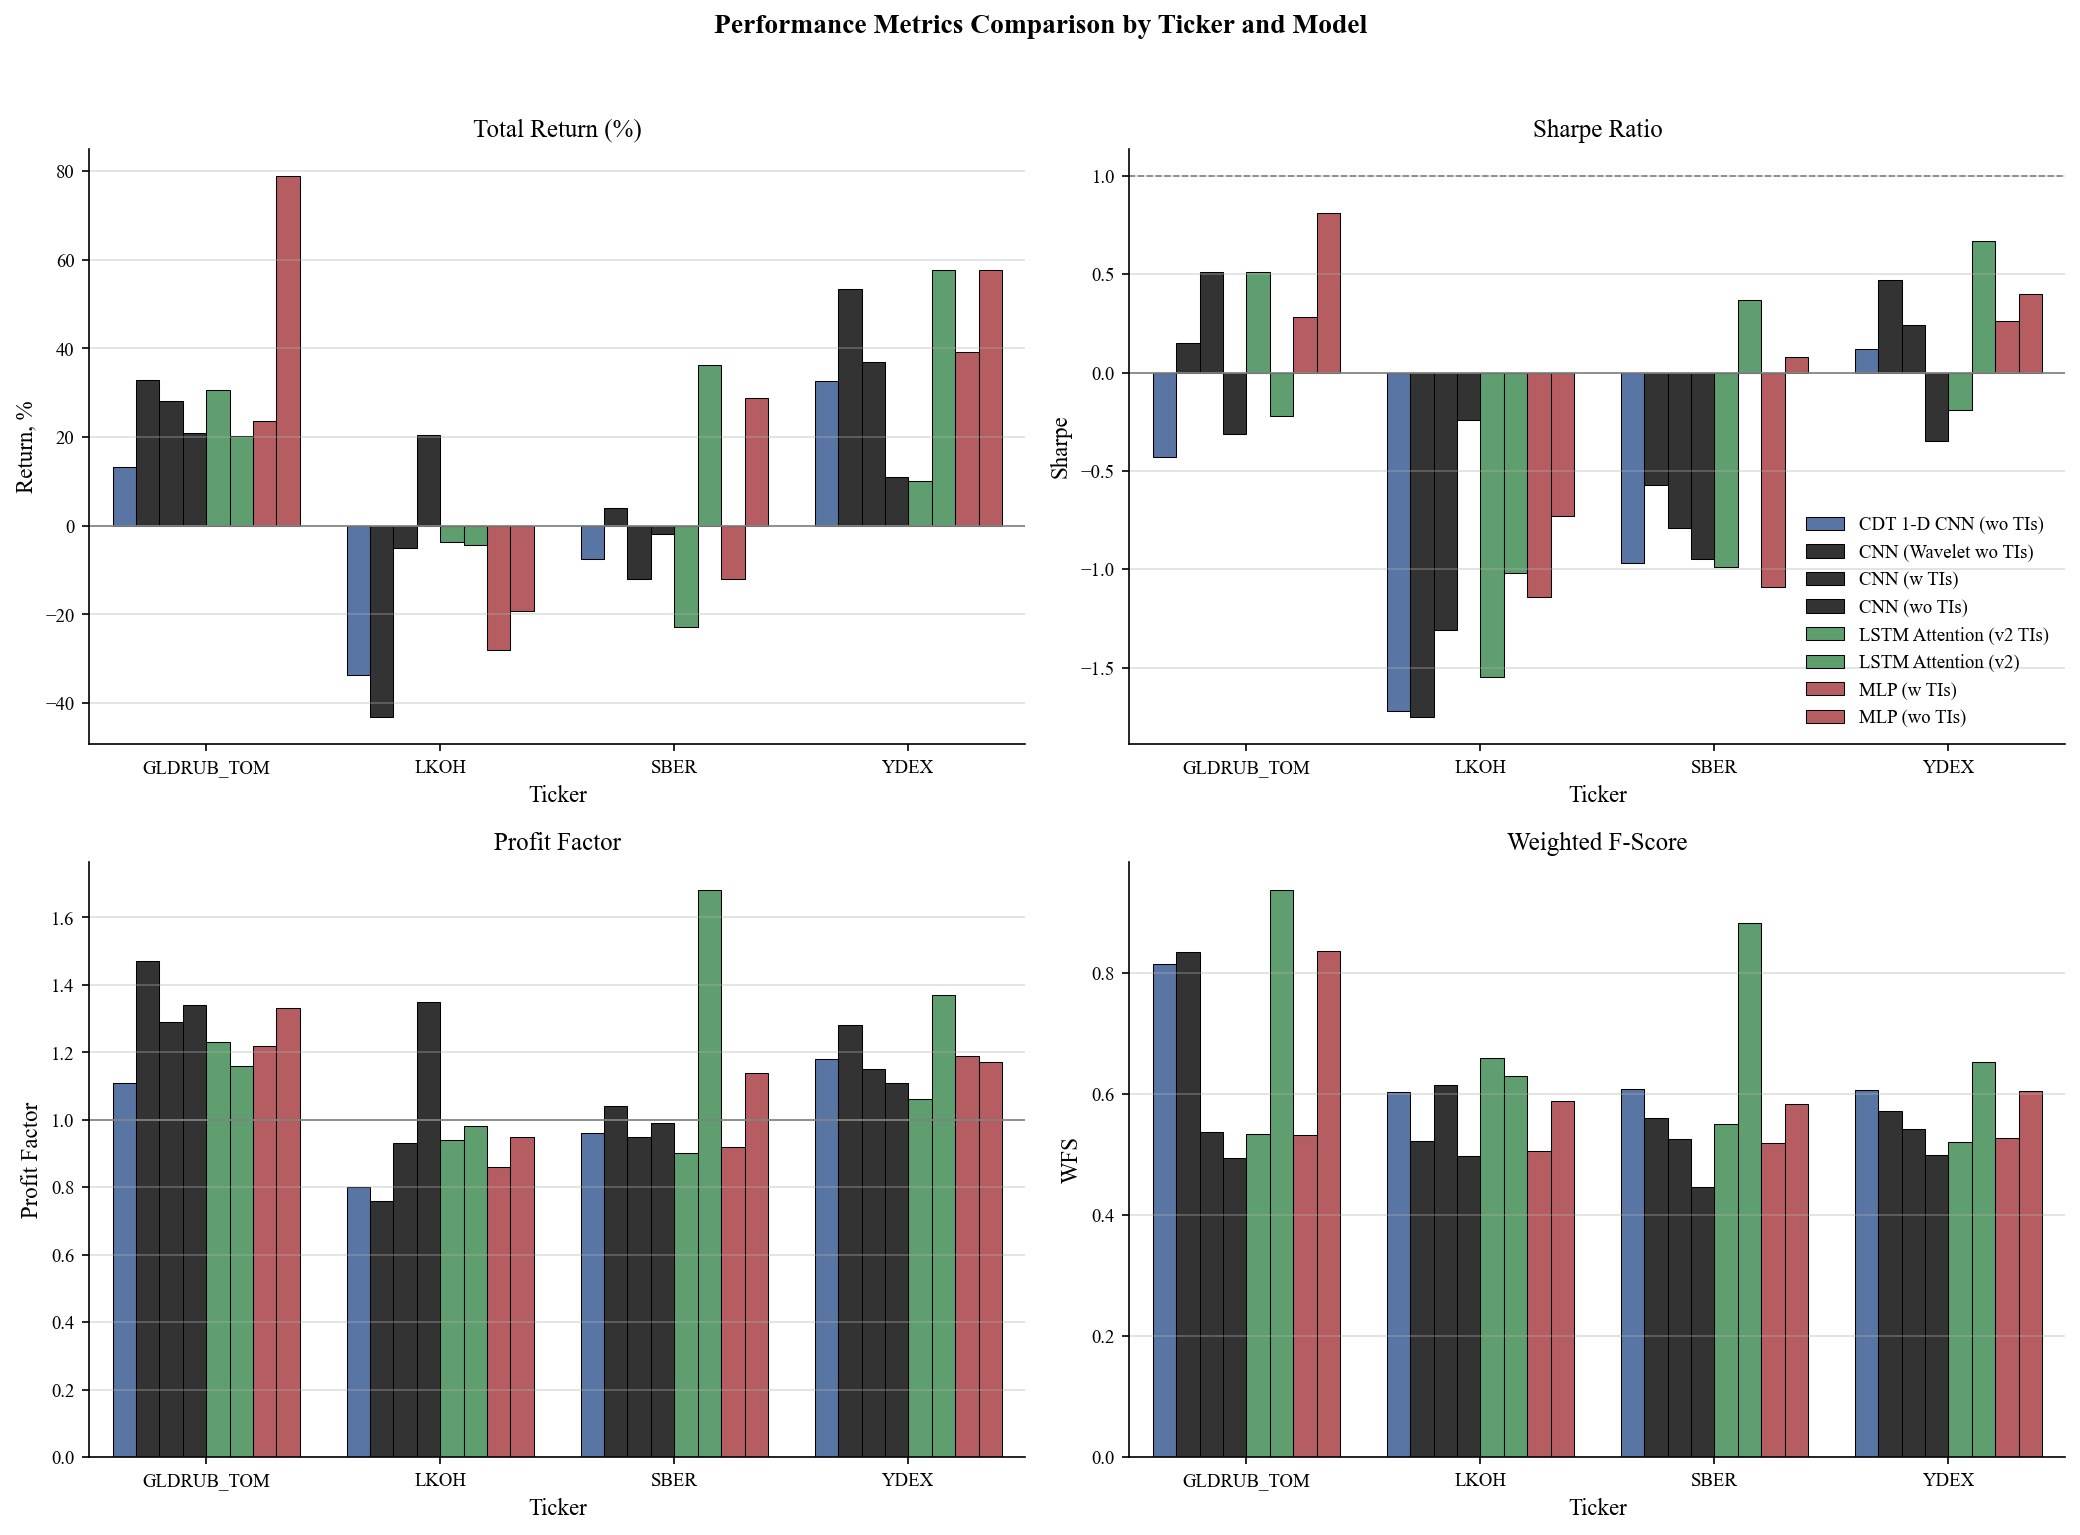

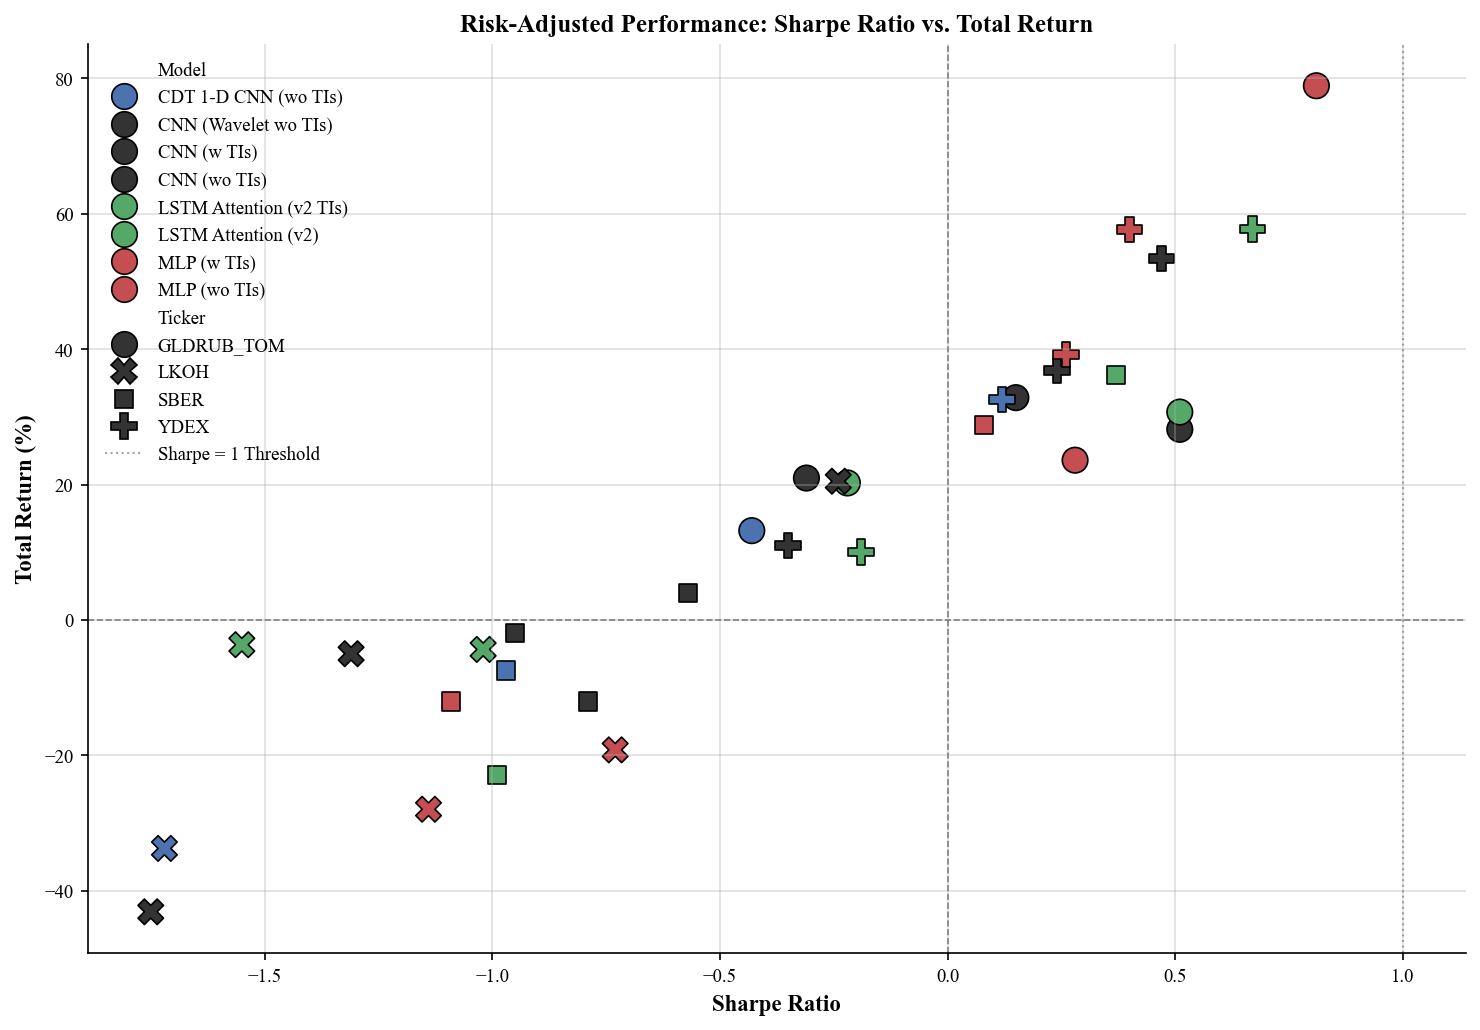

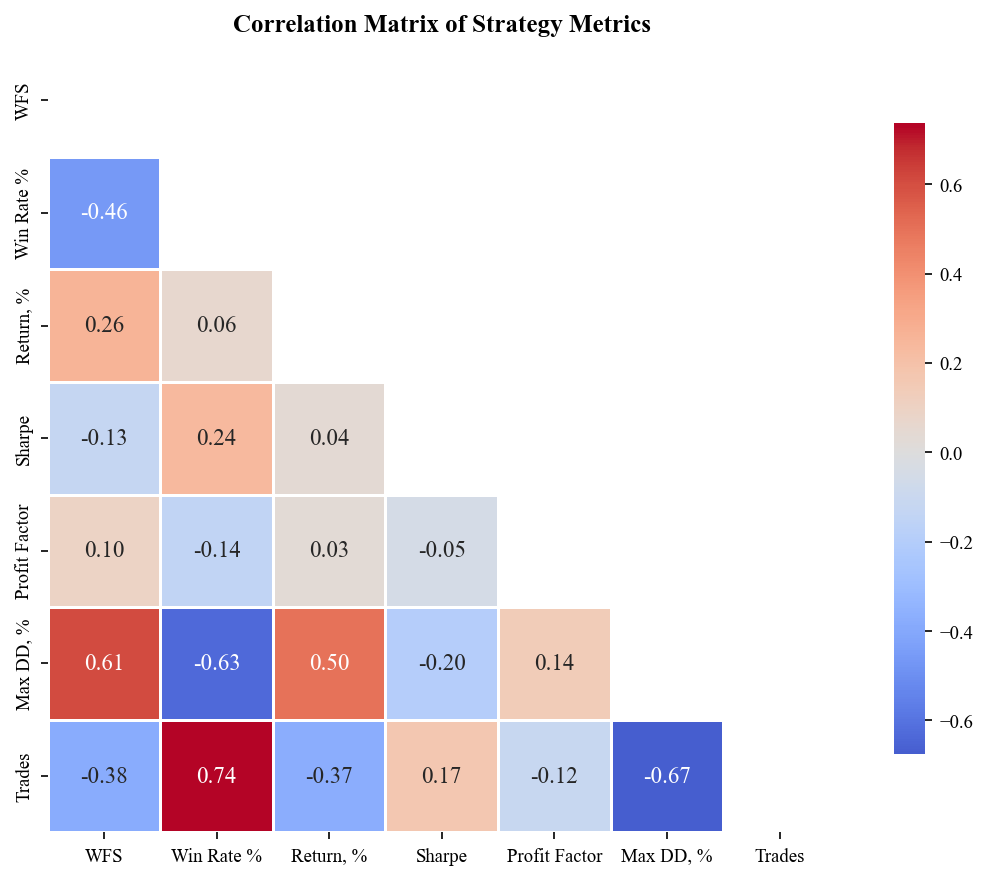

In [60]:
print("\nGenerating unified academic visualizations...")
plot_equity_curves(equity_curves_store, PLOTS_DIR)
plot_metrics_comparison(metrics_df, PLOTS_DIR)
plot_risk_return_scatter(metrics_df, PLOTS_DIR)
plot_correlation_heatmap(metrics_df, PLOTS_DIR)

In [61]:
if not metrics_df.empty:
    best_metrics_df = metrics_df.loc[metrics_df.groupby(['Ticker', 'Model'])['Sharpe'].idxmax()]
    best_metrics_df = best_metrics_df.sort_values(by=['Ticker', 'Sharpe'], ascending=[True, False])
    
    print("\n" + "="*110)
    print("TABLE 1: OUT-OF-SAMPLE PERFORMANCE COMPARISON (Best Threshold Selected by Sharpe Ratio)")
    print("="*110)
    cols_to_show = ['Ticker', 'Model', 'Threshold', 'WFS', 'Win Rate %', 'Profit Factor', 'Return, %', 'Max DD, %', 'Sharpe', 'Signif.']
    print(best_metrics_df[cols_to_show].to_string(index=False))
    
    # --- СОХРАНЕНИЕ В EXCEL ---
    excel_path = os.path.join(PLOTS_DIR, 'summary_table_word.xlsx')
    csv_path = os.path.join(PLOTS_DIR, 'summary_table.csv')
    
    best_metrics_df[cols_to_show].to_csv(csv_path, index=False)
    
    try:
        with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
            best_metrics_df[cols_to_show].to_excel(writer, index=False, sheet_name='Results')
            workbook = writer.book
            worksheet = writer.sheets['Results']
            
            header_format = workbook.add_format({
                'bold': True, 'text_wrap': True, 'valign': 'top', 'align': 'center', 'border': 1
            })
            cell_format = workbook.add_format({'border': 1, 'align': 'center'})
            
            for col_num, value in enumerate(best_metrics_df[cols_to_show].columns.values):
                worksheet.write(0, col_num, value, header_format)
            
            for row_num in range(1, len(best_metrics_df) + 1):
                for col_num in range(len(cols_to_show)):
                    worksheet.write(row_num, col_num, best_metrics_df.iloc[row_num-1, col_num], cell_format)
            
            worksheet.set_column('A:J', 16)
            
        print(f"\n[SUCCESS] Table saved to:\n  Excel (Copy-Paste to Word): {os.path.abspath(excel_path)}\n  CSV (backup): {os.path.abspath(csv_path)}")
        print("\n[INFO] How to insert into Word:\n1. Open the Excel file.\n2. Select the table (Ctrl+A).\n3. Copy (Ctrl+C).\n4. Go to Word and Paste (Ctrl+V). The table structure will be preserved.")
        
    except Exception as e:
        best_metrics_df[cols_to_show].to_excel(excel_path, index=False)
        print(f"\n[SUCCESS] Table saved to basic Excel: {os.path.abspath(excel_path)}")
        print("Install 'xlsxwriter' (pip install xlsxwriter) for better Word-ready formatting borders.")


TABLE 1: OUT-OF-SAMPLE PERFORMANCE COMPARISON (Best Threshold Selected by Sharpe Ratio)
    Ticker                   Model  Threshold    WFS  Win Rate %  Profit Factor  Return, %  Max DD, %  Sharpe Signif.
GLDRUB_TOM            MLP (wo TIs)       0.10 0.8365       37.64           1.33      78.92     -13.80    0.81     Yes
GLDRUB_TOM             CNN (w TIs)       0.35 0.5375       42.92           1.29      28.16      -9.32    0.51     Yes
GLDRUB_TOM LSTM Attention (v2 TIs)       0.10 0.5334       49.21           1.23      30.71     -13.21    0.51      No
GLDRUB_TOM             MLP (w TIs)       0.10 0.5327       32.13           1.22      23.60     -16.06    0.28      No
GLDRUB_TOM    CNN (Wavelet wo TIs)       0.50 0.8355       22.39           1.47      32.84      -8.13    0.15     Yes
GLDRUB_TOM     LSTM Attention (v2)       0.55 0.9369       37.77           1.16      20.24     -12.26   -0.22      No
GLDRUB_TOM            CNN (wo TIs)       0.25 0.4945       17.86           1.34      